In [1]:
# Import the necessary packages
import numpy as np
import sys
import glob
import os
import time
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from time import strftime, localtime
from matplotlib import rc
from matplotlib import font_manager
from prf_expect.utils import io
from prf_expect.utils.fit import PRFModel
from prf_expect.utils.beh import calculate_visual_angle
import cortex as cx

# Import settings data from yaml file
settings = io.load_settings()

# Define paths and data exp parameters
data_dir = Path.joinpath(
    Path(settings["general"]["data_dir"]),
    "data"
)
tasks = settings["design"]["tasks"]
space = settings["mri"]["space"]

Loading settings from /gpfs/home6/nwang/software/pRF_expect_pub/pRF_expect_analysis/prf_expect/settings.yml


In [2]:
cwd = os.getcwd()
font_dirs = [Path(cwd).parent.parent.parent / "arial"]
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

rc("pdf", fonttype=42, use14corefonts=False)
rc("axes", linewidth=0.5)
rc("font", **{"family": "Arial"})
rc("text", usetex=False)
rc("xtick", labelsize=6)
rc("ytick", labelsize=6)
rc("axes", labelsize=7)
rc("legend", fontsize=6)

plt.rcParams["xtick.major.width"] = 0.5
plt.rcParams["ytick.major.width"] = 0.5
plt.rcParams["xtick.major.size"] = 2
plt.rcParams["ytick.major.size"] = 2
plt.rcParams["xtick.minor.width"] = 0.5
plt.rcParams["ytick.minor.width"] = 0.5
plt.rcParams["xtick.minor.size"] = 1
plt.rcParams["ytick.minor.size"] = 1

# set up figure parameters
markeredgecolor = ".4"
bar_linewidth = 0.5
bar_alpha = 0.7
xticks_rotation = 45
marker = "s"
marker_edge_width = 0.5
markersize = 3 / 2.54
errorbar_linewidth = 0.5
errorbar_capsize = 2 / 2.54
errorbar_capthick = 0.5

In [3]:
r2_thre = 0.3
half_vis_angle = (
    calculate_visual_angle(
        settings["monitor"]["screen_size_cm"][1],
        settings["monitor"]["screen_distance_cm"],
    )
    / 2
)
comb_ROIs = True

In [4]:
rsq_list_omission = []
rsq_list_sparse = []
rsq_list_violation = []
rsq_list_standard = []

rsq_list_omission_stim_present = []
rsq_list_sparse_stim_present = []
rsq_list_violation_stim_present = []

for subject in settings["general"]["subject_list"]:
    
    
    tsv_name = Path.joinpath(
        data_dir,
        "derivatives",
        "prf_data",
        subject,
        "ses-1",
        "prf_fits",
        "prf_params",
        f"{subject}_ses-1_final-fit_space-{space}_model-norm_stage-iter_desc-prf_params.tsv",
    )
    data = pd.read_csv(
        tsv_name,
        sep="\t",
        header=0,
    )
    mask = data["r2"] >= r2_thre
    mask_broadcasted = np.tile(mask, (data.shape[1], 1)).T
    params = data.where(mask_broadcasted)
    params_np = params.to_numpy()
    sub_vis_rsq = params["r2"]
    sub_vis_ecc = params["ecc"]
    
    sub_vis_rsq[sub_vis_ecc > half_vis_angle] = np.nan

    sub_dir = os.path.join(data_dir, "derivatives", "prf_data", subject, "ses-1")
    prf_fits_dir = os.path.join(sub_dir, "prf_fits")
    pred_dir = os.path.join(prf_fits_dir, "prf_predictions")
    omission_rsq = np.load(os.path.join(pred_dir, f"{subject}_ses-1_prf_prediction_rsq_omission.npy"))
    sparse_rsq = np.load(os.path.join(pred_dir, f"{subject}_ses-1_prf_prediction_rsq_sparse.npy"))
    violation_rsq = np.load(os.path.join(pred_dir, f"{subject}_ses-1_prf_prediction_rsq_violation.npy"))

    omission_rsq_stim_present = np.load(os.path.join(pred_dir, f"{subject}_ses-1_prf_prediction_rsq_omission_stim_present.npy"))
    sparse_rsq_stim_present = np.load(os.path.join(pred_dir, f"{subject}_ses-1_prf_prediction_rsq_sparse_stim_present.npy"))
    violation_rsq_stim_present = np.load(os.path.join(pred_dir, f"{subject}_ses-1_prf_prediction_rsq_violation_stim_present.npy"))

    omission_rsq[~mask] = np.nan
    omission_rsq[sub_vis_ecc > half_vis_angle] = np.nan
    sparse_rsq[~mask] = np.nan
    sparse_rsq[sub_vis_ecc > half_vis_angle] = np.nan
    violation_rsq[~mask] = np.nan
    violation_rsq[sub_vis_ecc > half_vis_angle] = np.nan

    omission_rsq_stim_present[~mask] = np.nan
    omission_rsq_stim_present[sub_vis_ecc > half_vis_angle] = np.nan
    sparse_rsq_stim_present[~mask] = np.nan
    sparse_rsq_stim_present[sub_vis_ecc > half_vis_angle] = np.nan
    violation_rsq_stim_present[~mask] = np.nan
    violation_rsq_stim_present[sub_vis_ecc > half_vis_angle] = np.nan

    rsq_list_omission.append(omission_rsq)
    rsq_list_sparse.append(sparse_rsq)
    rsq_list_violation.append(violation_rsq)
    rsq_list_standard.append(sub_vis_rsq)

    rsq_list_omission_stim_present.append(omission_rsq_stim_present)
    rsq_list_sparse_stim_present.append(sparse_rsq_stim_present)
    rsq_list_violation_stim_present.append(violation_rsq_stim_present)

rsq_list_omission = np.array(rsq_list_omission)
rsq_list_sparse = np.array(rsq_list_sparse)
rsq_list_violation = np.array(rsq_list_violation)
rsq_list_standard = np.array(rsq_list_standard)

rsq_list_omission[rsq_list_omission < 0] = 0
rsq_list_sparse[rsq_list_sparse < 0] = 0
rsq_list_violation[rsq_list_violation < 0] = 0
rsq_list_standard[rsq_list_standard < 0] = 0

rsq_list_omission_stim_present = np.array(rsq_list_omission_stim_present)
rsq_list_sparse_stim_present = np.array(rsq_list_sparse_stim_present)
rsq_list_violation_stim_present = np.array(rsq_list_violation_stim_present)

rsq_list_omission_stim_present[rsq_list_omission_stim_present < 0] = 0
rsq_list_sparse_stim_present[rsq_list_sparse_stim_present < 0] = 0
rsq_list_violation_stim_present[rsq_list_violation_stim_present < 0] = 0

In [5]:
rsq_list_omission_stim_present[0]


array([nan,  0., nan, ..., nan, nan, nan], shape=(327684,))

In [6]:
rsq_list_omission[0]

array([nan,  0., nan, ..., nan, nan, nan], shape=(327684,), dtype=float32)

In [7]:
ROIs_list_long = (
    "V1",
    "V2",
    "V3",
    "V3A",
    "V3B",
    "V4",
    "LO1",
    "LO2",
    "VO1",
    "VO2",
    "hMT",
    "MST",
    "IPS0",
    "IPS1",
    "IPS2",
    "IPS3",
    "IPS4",
    "IPS5",
)
roi_verts = cx.get_roi_verts("fsaverage", ROIs_list_long)

In [8]:
combined_roi_verts = {}
combined_roi_verts["V1"] = roi_verts["V1"]
combined_roi_verts["V2"] = roi_verts["V2"]
combined_roi_verts["V3"] = roi_verts["V3"]
combined_roi_verts["V3AB"] = np.concatenate((roi_verts["V3A"], roi_verts["V3B"]))
combined_roi_verts["V4"] = roi_verts["V4"]
combined_roi_verts["LO"] = np.concatenate((roi_verts["LO1"], roi_verts["LO2"]))
combined_roi_verts["TO"] = np.concatenate((roi_verts["hMT"], roi_verts["MST"]))
combined_roi_verts["VO"] = np.concatenate((roi_verts["VO1"], roi_verts["VO2"]))
combined_roi_verts["earlyIPS"] = np.concatenate((roi_verts["IPS0"], 
                                            roi_verts["IPS1"], 
                                            roi_verts["IPS2"],))
combined_roi_verts["lateIPS"] = np.concatenate((roi_verts["IPS3"], 
                                            roi_verts["IPS4"], 
                                            roi_verts["IPS5"]))
if comb_ROIs == True:
    rois = combined_roi_verts
else:
    rois = roi_verts

ROIs_list = list(rois.keys())
vis_verts = np.array([], dtype=int)
for roi in rois:
    vis_verts = np.concatenate((vis_verts, rois[roi]))

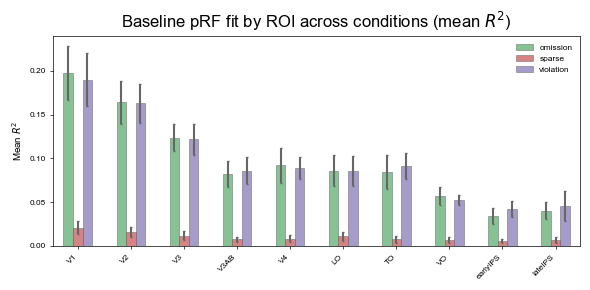

In [9]:
# for each omission/sparse/violation condition, plot average r2 for each ROI
condition_arrays = {
    "omission": rsq_list_omission,
    "sparse": rsq_list_sparse,
    "violation": rsq_list_violation,
}

roi_means = {cond: [] for cond in condition_arrays}
roi_sems = {cond: [] for cond in condition_arrays}

for roi in ROIs_list:
    verts = rois[roi].astype(int)
    for cond, arr in condition_arrays.items():
        roi_vals = arr[:, verts]  # subjects x vertices
        subj_means = np.nanmean(roi_vals, axis=1)  # mean per subject in this ROI, ignoring NaN
        roi_means[cond].append(np.nanmean(subj_means))
        n_valid = np.isfinite(subj_means).sum()
        if n_valid > 1:
            roi_sems[cond].append(np.nanstd(subj_means, ddof=1) / np.sqrt(n_valid))
        else:
            roi_sems[cond].append(np.nan)

cond_order = ["omission", "sparse", "violation"]
colors = {
    "omission": "#55a868",
    "sparse": "#c44e52",
    "violation": "#8172b3",
}

x = np.arange(len(ROIs_list))
width = 0.18
fig, ax = plt.subplots(figsize=(6, 3))

for i, cond in enumerate(cond_order):
    offsets = (i - (len(cond_order) - 1) / 2) * width
    ax.bar(
        x + offsets,
        roi_means[cond],
        width=width,
        yerr=roi_sems[cond],
        label=cond,
        color=colors.get(cond, "0.7"),
        edgecolor=markeredgecolor,
        linewidth=bar_linewidth,
        alpha=bar_alpha,
        capsize=errorbar_capsize,
        ecolor=markeredgecolor,
    )

ax.set_xticks(x)
ax.set_xticklabels(ROIs_list, rotation=xticks_rotation, ha="right")
ax.set_ylabel("Mean $R^2$")
ax.set_title("Baseline pRF fit by ROI across conditions (mean $R^2$)")
ax.legend(frameon=False)
ax.margins(x=0.02)
plt.tight_layout()

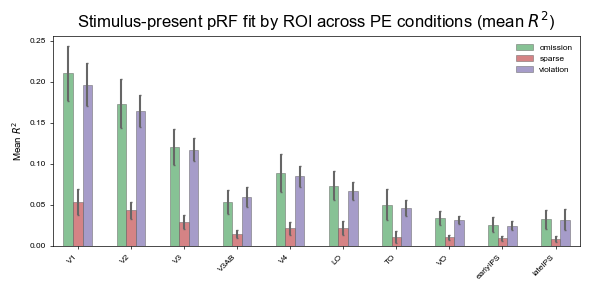

In [10]:
# for each omission/sparse/violation condition, plot average r2 for each ROI
condition_arrays = {
    "omission": rsq_list_omission_stim_present,
    "sparse": rsq_list_sparse_stim_present,
    "violation": rsq_list_violation_stim_present,
}

roi_means = {cond: [] for cond in condition_arrays}
roi_sems = {cond: [] for cond in condition_arrays}

for roi in ROIs_list:
    verts = rois[roi].astype(int)
    for cond, arr in condition_arrays.items():
        roi_vals = arr[:, verts]  # subjects x vertices
        subj_means = np.nanmean(roi_vals, axis=1)  # mean per subject in this ROI, ignoring NaN
        roi_means[cond].append(np.nanmean(subj_means))
        n_valid = np.isfinite(subj_means).sum()
        if n_valid > 1:
            roi_sems[cond].append(np.nanstd(subj_means, ddof=1) / np.sqrt(n_valid))
        else:
            roi_sems[cond].append(np.nan)

cond_order = ["omission", "sparse", "violation"]
colors = {
    "omission": "#55a868",
    "sparse": "#c44e52",
    "violation": "#8172b3",
}

x = np.arange(len(ROIs_list))
width = 0.18
fig, ax = plt.subplots(figsize=(6, 3))

for i, cond in enumerate(cond_order):
    offsets = (i - (len(cond_order) - 1) / 2) * width
    ax.bar(
        x + offsets,
        roi_means[cond],
        width=width,
        yerr=roi_sems[cond],
        label=cond,
        color=colors.get(cond, "0.7"),
        edgecolor=markeredgecolor,
        linewidth=bar_linewidth,
        alpha=bar_alpha,
        capsize=errorbar_capsize,
        ecolor=markeredgecolor,
    )

ax.set_xticks(x)
ax.set_xticklabels(ROIs_list, rotation=xticks_rotation, ha="right")
ax.set_ylabel("Mean $R^2$")
ax.set_title("Stimulus-present pRF fit by ROI across PE conditions (mean $R^2$)")
ax.legend(frameon=False)
ax.margins(x=0.02)
plt.tight_layout()

Found 9 LOO fit files for sub-001, condition=standard.


/scratch-local/68123/ipykernel_2013818/1179988458.py:96: RuntimeWarning: Mean of empty slice
  loo_runavg[cond].append(np.nanmean(np.stack(fold_r2, axis=0), axis=0))
/scratch-local/68123/ipykernel_2013818/1179988458.py:98: RuntimeWarning: Mean of empty slice
  np.nanmean(np.stack(fold_r2_over_nc, axis=0), axis=0)


Found 9 LOO fit files for sub-001, condition=standardconcatenated.


/scratch-local/68123/ipykernel_2013818/1179988458.py:96: RuntimeWarning: Mean of empty slice
  loo_runavg[cond].append(np.nanmean(np.stack(fold_r2, axis=0), axis=0))
/scratch-local/68123/ipykernel_2013818/1179988458.py:98: RuntimeWarning: Mean of empty slice
  np.nanmean(np.stack(fold_r2_over_nc, axis=0), axis=0)


Found 3 LOO fit files for sub-001, condition=omission.


...

/scratch-local/68123/ipykernel_2013818/1179988458.py:96: RuntimeWarning: Mean of empty slice
  loo_runavg[cond].append(np.nanmean(np.stack(fold_r2, axis=0), axis=0))
/scratch-local/68123/ipykernel_2013818/1179988458.py:98: RuntimeWarning: Mean of empty slice
  np.nanmean(np.stack(fold_r2_over_nc, axis=0), axis=0)


Found 3 LOO fit files for sub-012, condition=sparse.


/scratch-local/68123/ipykernel_2013818/1179988458.py:96: RuntimeWarning: Mean of empty slice
  loo_runavg[cond].append(np.nanmean(np.stack(fold_r2, axis=0), axis=0))
/scratch-local/68123/ipykernel_2013818/1179988458.py:98: RuntimeWarning: Mean of empty slice
  np.nanmean(np.stack(fold_r2_over_nc, axis=0), axis=0)


Found 3 LOO fit files for sub-012, condition=violation.


/scratch-local/68123/ipykernel_2013818/1179988458.py:96: RuntimeWarning: Mean of empty slice
  loo_runavg[cond].append(np.nanmean(np.stack(fold_r2, axis=0), axis=0))
/scratch-local/68123/ipykernel_2013818/1179988458.py:98: RuntimeWarning: Mean of empty slice
  np.nanmean(np.stack(fold_r2_over_nc, axis=0), axis=0)


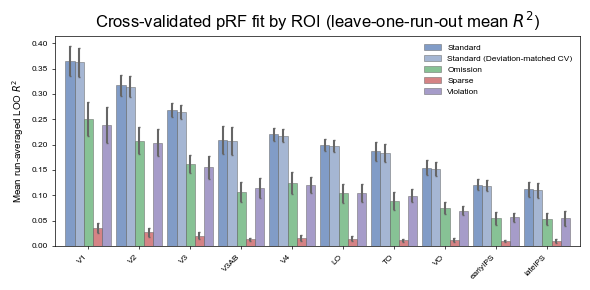

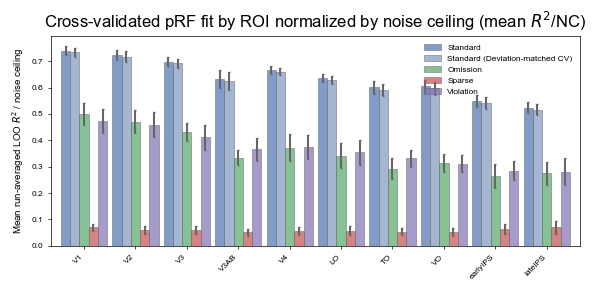

In [11]:
# load run-wise LOO fits and average loo_r2 across runs for each subject and condition
loo_conditions = ("standard", "standardconcatenated", "omission", "sparse", "violation")
loo_runavg = {cond: [] for cond in loo_conditions}
loo_runavg_nc = {cond: [] for cond in loo_conditions}

for subject in settings["general"]["subject_list"]:
    sub_params_dir = (
        data_dir
        / "derivatives"
        / "prf_data"
        / subject
        / "ses-1"
        / "prf_fits"
        / "prf_params"
    )

    final_tsv = (
        sub_params_dir
        / f"{subject}_ses-1_final-fit_space-{space}_model-norm_stage-iter_desc-prf_params.tsv"
    )
    final_df = pd.read_csv(final_tsv, sep="\t")
    base_mask = (final_df["r2"].to_numpy() >= r2_thre) & (
        final_df["ecc"].to_numpy() <= half_vis_angle
    )

    noise_ceiling_file = (
        data_dir
        / "derivatives"
        / "prf_data"
        / subject
        / "ses-1"
        / "cut_and_averaged"
        / "noise_ceiling"
        / f"{subject}_ses-1_task-pRF_space-{space}_desc-noiseceiling_during_stim_present.npy"
    )
    if not noise_ceiling_file.exists():
        raise FileNotFoundError(
            f"Missing noise ceiling file for {subject}: {noise_ceiling_file}"
        )

    subj_noise_ceiling = np.load(noise_ceiling_file).astype(float)
    if subj_noise_ceiling.shape[0] != base_mask.shape[0]:
        raise ValueError(
            f"Noise ceiling size mismatch for {subject}: "
            f"{subj_noise_ceiling.shape[0]} vs {base_mask.shape[0]}"
        )

    subj_noise_ceiling[~base_mask] = np.nan
    subj_noise_ceiling[subj_noise_ceiling <= 0] = np.nan

    cv_dir = sub_params_dir / "cv"
    for cond in loo_conditions:
        fold_files = sorted(
            cv_dir.glob(
                f"{subject}_ses-1_{cond}-fit_space-{space}_loo-*_model-norm_stage-iter_desc-prf_params.tsv"
            )
        )
        print(f"Found {len(fold_files)} LOO fit files for {subject}, condition={cond}.")
        if len(fold_files) == 0:
            raise FileNotFoundError(
                f"No LOO fit files found for {subject}, condition={cond} in {cv_dir}."
            )

        fold_r2 = []
        fold_r2_over_nc = []
        for fold_file in fold_files:
            fold_df = pd.read_csv(fold_file, sep="\t")
            if "loo_r2_stim_present" in fold_df.columns:
                r2_col = "loo_r2_stim_present"
            else:
                raise ValueError(
                    f"Missing both 'loo_r2_stim_present' and 'loo_r2' columns in {fold_file}."
                )

            fold_vals = fold_df[r2_col].to_numpy(dtype=float)
            if fold_vals.shape[0] != base_mask.shape[0]:
                raise ValueError(
                    f"Voxel mismatch for {subject}, condition={cond}, file={fold_file.name}: "
                    f"{fold_vals.shape[0]} vs {base_mask.shape[0]}"
                )

            fold_vals[~base_mask] = np.nan
            fold_vals[fold_vals < 0] = 0
            fold_r2.append(fold_vals)

            with np.errstate(divide="ignore", invalid="ignore"):
                fold_vals_over_nc = np.divide(
                    fold_vals,
                    subj_noise_ceiling,
                    out=np.full_like(fold_vals, np.nan, dtype=float),
                    where=np.isfinite(subj_noise_ceiling) & (subj_noise_ceiling > 0),
                )
            fold_vals_over_nc[fold_vals_over_nc > 1] = 1
            fold_r2_over_nc.append(fold_vals_over_nc)

        loo_runavg[cond].append(np.nanmean(np.stack(fold_r2, axis=0), axis=0))
        loo_runavg_nc[cond].append(
            np.nanmean(np.stack(fold_r2_over_nc, axis=0), axis=0)
        )

for cond in loo_conditions:
    loo_runavg[cond] = np.array(loo_runavg[cond])
    loo_runavg_nc[cond] = np.array(loo_runavg_nc[cond])

# plot run-averaged loo_r2 for each ROI
condition_arrays = loo_runavg
roi_means = {cond: [] for cond in condition_arrays}
roi_sems = {cond: [] for cond in condition_arrays}

for roi in ROIs_list:
    verts = rois[roi].astype(int)
    for cond, arr in condition_arrays.items():
        roi_vals = arr[:, verts]  # subjects x vertices
        subj_means = np.nanmean(roi_vals, axis=1)
        roi_means[cond].append(np.nanmean(subj_means))

        n_valid = np.isfinite(subj_means).sum()
        if n_valid > 1:
            roi_sems[cond].append(np.nanstd(subj_means, ddof=1) / np.sqrt(n_valid))
        else:
            roi_sems[cond].append(np.nan)

cond_order = ["standard", "standardconcatenated", "omission", "sparse", "violation"]
colors = {
    "standard": "#4c72b0",
    "standardconcatenated": "#7f98c1",
    "omission": "#55a868",
    "sparse": "#c44e52",
    "violation": "#8172b3",
}
display_labels = {
    "standard": "Standard",
    "standardconcatenated": "Standard (Deviation-matched CV)",
    "omission": "Omission",
    "sparse": "Sparse",
    "violation": "Violation",
}

x = np.arange(len(ROIs_list))
width = 0.18
fig, ax = plt.subplots(figsize=(6, 3))

for i, cond in enumerate(cond_order):
    offsets = (i - (len(cond_order) - 1) / 2) * width
    ax.bar(
        x + offsets,
        roi_means[cond],
        width=width,
        yerr=roi_sems[cond],
        label=display_labels.get(cond, cond),
        color=colors.get(cond, "0.7"),
        edgecolor=markeredgecolor,
        linewidth=bar_linewidth,
        alpha=bar_alpha,
        capsize=errorbar_capsize,
        ecolor=markeredgecolor,
    )

ax.set_xticks(x)
ax.set_xticklabels(ROIs_list, rotation=xticks_rotation, ha="right")
ax.set_ylabel("Mean run-averaged LOO $R^2$")
ax.set_title("Cross-validated pRF fit by ROI (leave-one-run-out mean $R^2$)")
ax.legend(frameon=False)
ax.margins(x=0.02)
plt.tight_layout()

# plot run-averaged loo_r2 divided by noise ceiling for each ROI
condition_arrays_nc = loo_runavg_nc
roi_means_nc = {cond: [] for cond in condition_arrays_nc}
roi_sems_nc = {cond: [] for cond in condition_arrays_nc}

for roi in ROIs_list:
    verts = rois[roi].astype(int)
    for cond, arr in condition_arrays_nc.items():
        roi_vals = arr[:, verts]  # subjects x vertices
        subj_means = np.nanmean(roi_vals, axis=1)
        roi_means_nc[cond].append(np.nanmean(subj_means))

        n_valid = np.isfinite(subj_means).sum()
        if n_valid > 1:
            roi_sems_nc[cond].append(np.nanstd(subj_means, ddof=1) / np.sqrt(n_valid))
        else:
            roi_sems_nc[cond].append(np.nan)

fig, ax = plt.subplots(figsize=(6, 3))

for i, cond in enumerate(cond_order):
    offsets = (i - (len(cond_order) - 1) / 2) * width
    ax.bar(
        x + offsets,
        roi_means_nc[cond],
        width=width,
        yerr=roi_sems_nc[cond],
        label=display_labels.get(cond, cond),
        color=colors.get(cond, "0.7"),
        edgecolor=markeredgecolor,
        linewidth=bar_linewidth,
        alpha=bar_alpha,
        capsize=errorbar_capsize,
        ecolor=markeredgecolor,
    )

ax.set_xticks(x)
ax.set_xticklabels(ROIs_list, rotation=xticks_rotation, ha="right")
ax.set_ylabel("Mean run-averaged LOO $R^2$ / noise ceiling")
ax.set_title(
    "Cross-validated pRF fit by ROI normalized by noise ceiling (mean $R^2$/NC)"
 )
ax.legend(frameon=False)
ax.margins(x=0.02)
plt.tight_layout()